# 🏥 AI Healthcare Assistant Platform
## Phase 1: Project Setup & Database Layer
**Skills:** Python · SQL · Data Engineering

---
### What we build in this phase:
- Install all project dependencies
- Create SQLite database (simulates PostgreSQL locally)
- Design patient, symptoms, predictions & image tables
- Build a `DatabaseManager` class with full CRUD operations
- Seed the database with realistic synthetic patient data
- Run SQL queries and analysis on the data

## Step 1: Install Dependencies

In [1]:
# Install all libraries needed across the entire project
!pip install pandas numpy scikit-learn torch torchvision
!pip install transformers sentence-transformers
!pip install fastapi uvicorn python-multipart
!pip install opencv-python-headless Pillow
!pip install langchain openai faiss-cpu
!pip install matplotlib seaborn plotly
!pip install faker sqlalchemy
print('✅ All dependencies installed!')

   ---------------------------------------- 0.0/117.5 kB ? eta -:--:--
   --------------------------- ------------ 81.9/117.5 kB ? eta -:--:--
   ---------------------------------------- 117.5/117.5 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.3 kB ? eta -:--:--
   ---------------------------------------- 73.3/73.3 kB 4.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.3 MB 1.8 MB/s eta 0:00:07
   - -------------------------------------- 0.5/12.3 MB 5.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/12.3 MB 8.8 MB/s eta 0:00:02
   ------- -------------------------------- 2.3/12.3 MB 12.4 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.3 MB 12.7 MB/s eta 0:00:01
   ------------- -------------------------- 4.0/12.3 MB 14.4 MB/s eta 0:00:01
   -------------- ------------------------- 4.6/12.3 MB 14.7 MB/s eta 0:00:01
   -------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.2.17 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.6 which is incompatible.
langchain-chroma 1.1.0 requires langchain-core<2.0.0,>=1.1.3, but you have langchain-core 0.2.43 which is incompatible.
langchain-community 0.2.19 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.6 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.4.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.6 which is incompatible.
streamlit 1.

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 1.1.0 requires langchain-core<2.0.0,>=1.1.3, but you have langchain-core 0.2.43 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 24.2 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.
streamlit 1.32.0 requires rich<14,>=10.14.0, but you have rich 14.3.4 which is incompatible.


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -- ------------------------------------- 0.1/2.0 MB 7.5 MB/s eta 0:00:01
   ------------ --------------------------- 0.6/2.0 MB 9.7 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 14.3 MB/s eta 0:00:00
✅ All dependencies installed!


## Step 2: Project Folder Structure

In [3]:
import os

folders = [
    'healthcare_ai/data',
    'healthcare_ai/models',
    'healthcare_ai/api',
    'healthcare_ai/chatbot',
    'healthcare_ai/vision',
    'healthcare_ai/ml',
    'healthcare_ai/uploads/images',
    'healthcare_ai/notebooks',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'📁 Created: {folder}')

print('\n✅ Project structure ready!')

📁 Created: healthcare_ai/data
📁 Created: healthcare_ai/models
📁 Created: healthcare_ai/api
📁 Created: healthcare_ai/chatbot
📁 Created: healthcare_ai/vision
📁 Created: healthcare_ai/ml
📁 Created: healthcare_ai/uploads/images
📁 Created: healthcare_ai/notebooks

✅ Project structure ready!


## Step 3: Database Schema Design

In [5]:
import sqlite3
import os

DB_PATH = 'healthcare_ai/data/healthcare.db'

def create_database():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    # --- Table 1: Patients ---
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS patients (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            name        TEXT NOT NULL,
            age         INTEGER,
            gender      TEXT,
            email       TEXT UNIQUE,
            blood_type  TEXT,
            created_at  TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')

    # --- Table 2: Patient Vitals ---
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS vitals (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id      INTEGER,
            glucose         REAL,
            blood_pressure  REAL,
            bmi             REAL,
            insulin         REAL,
            heart_rate      INTEGER,
            recorded_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (patient_id) REFERENCES patients(id)
        )
    ''')

    # --- Table 3: Symptom Logs (Chatbot input) ---
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS symptom_logs (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id      INTEGER,
            symptoms_text   TEXT,
            bot_response    TEXT,
            severity        TEXT,
            created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (patient_id) REFERENCES patients(id)
        )
    ''')

    # --- Table 4: ML Risk Predictions ---
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS risk_predictions (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id      INTEGER,
            disease         TEXT,
            risk_score      REAL,
            risk_level      TEXT,
            model_version   TEXT,
            predicted_at    TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (patient_id) REFERENCES patients(id)
        )
    ''')

    # --- Table 5: Image Scans (Computer Vision) ---
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS image_scans (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id      INTEGER,
            image_path      TEXT,
            scan_type       TEXT,
            cv_diagnosis    TEXT,
            confidence      REAL,
            scanned_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (patient_id) REFERENCES patients(id)
        )
    ''')

    conn.commit()
    conn.close()
    print('✅ Database schema created successfully!')
    print(f'📦 Database location: {DB_PATH}')

create_database()

✅ Database schema created successfully!
📦 Database location: healthcare_ai/data/healthcare.db


## Step 4: DatabaseManager Class (Reusable across all phases)

In [7]:
import sqlite3
import pandas as pd
from datetime import datetime

class DatabaseManager:
    """Central database handler for the Healthcare AI Platform."""

    def __init__(self, db_path=DB_PATH):
        self.db_path = db_path

    def _connect(self):
        return sqlite3.connect(self.db_path)

    # ── Patients ──────────────────────────────────────────────
    def add_patient(self, name, age, gender, email, blood_type):
        with self._connect() as conn:
            conn.execute(
                'INSERT OR IGNORE INTO patients (name, age, gender, email, blood_type) VALUES (?,?,?,?,?)',
                (name, age, gender, email, blood_type)
            )
        return self.get_patient_by_email(email)

    def get_patient_by_email(self, email):
        with self._connect() as conn:
            return pd.read_sql('SELECT * FROM patients WHERE email=?', conn, params=(email,))

    def get_all_patients(self):
        with self._connect() as conn:
            return pd.read_sql('SELECT * FROM patients', conn)

    # ── Vitals ────────────────────────────────────────────────
    def add_vitals(self, patient_id, glucose, blood_pressure, bmi, insulin, heart_rate):
        with self._connect() as conn:
            conn.execute(
                'INSERT INTO vitals (patient_id, glucose, blood_pressure, bmi, insulin, heart_rate) VALUES (?,?,?,?,?,?)',
                (patient_id, glucose, blood_pressure, bmi, insulin, heart_rate)
            )

    def get_vitals(self, patient_id):
        with self._connect() as conn:
            return pd.read_sql('SELECT * FROM vitals WHERE patient_id=?', conn, params=(patient_id,))

    # ── Symptom Logs ──────────────────────────────────────────
    def log_symptom(self, patient_id, symptoms_text, bot_response, severity):
        with self._connect() as conn:
            conn.execute(
                'INSERT INTO symptom_logs (patient_id, symptoms_text, bot_response, severity) VALUES (?,?,?,?)',
                (patient_id, symptoms_text, bot_response, severity)
            )

    def get_symptom_logs(self, patient_id):
        with self._connect() as conn:
            return pd.read_sql('SELECT * FROM symptom_logs WHERE patient_id=?', conn, params=(patient_id,))

    # ── Risk Predictions ──────────────────────────────────────
    def save_prediction(self, patient_id, disease, risk_score, risk_level, model_version):
        with self._connect() as conn:
            conn.execute(
                'INSERT INTO risk_predictions (patient_id, disease, risk_score, risk_level, model_version) VALUES (?,?,?,?,?)',
                (patient_id, disease, risk_score, risk_level, model_version)
            )

    def get_predictions(self, patient_id):
        with self._connect() as conn:
            return pd.read_sql('SELECT * FROM risk_predictions WHERE patient_id=?', conn, params=(patient_id,))

    # ── Image Scans ───────────────────────────────────────────
    def save_scan(self, patient_id, image_path, scan_type, cv_diagnosis, confidence):
        with self._connect() as conn:
            conn.execute(
                'INSERT INTO image_scans (patient_id, image_path, scan_type, cv_diagnosis, confidence) VALUES (?,?,?,?,?)',
                (patient_id, image_path, scan_type, cv_diagnosis, confidence)
            )

    # ── Analytics Queries ─────────────────────────────────────
    def get_high_risk_patients(self, threshold=0.7):
        query = '''
            SELECT p.name, p.age, p.gender, r.disease, r.risk_score, r.risk_level
            FROM patients p
            JOIN risk_predictions r ON p.id = r.patient_id
            WHERE r.risk_score >= ?
            ORDER BY r.risk_score DESC
        '''
        with self._connect() as conn:
            return pd.read_sql(query, conn, params=(threshold,))

    def get_summary_stats(self):
        queries = {
            'total_patients': 'SELECT COUNT(*) as count FROM patients',
            'total_predictions': 'SELECT COUNT(*) as count FROM risk_predictions',
            'total_scans': 'SELECT COUNT(*) as count FROM image_scans',
            'avg_risk_score': 'SELECT ROUND(AVG(risk_score),3) as avg FROM risk_predictions',
        }
        results = {}
        with self._connect() as conn:
            for key, q in queries.items():
                results[key] = pd.read_sql(q, conn).iloc[0, 0]
        return results

db = DatabaseManager()
print('✅ DatabaseManager ready!')

✅ DatabaseManager ready!


## Step 5: Seed with Synthetic Patient Data

In [9]:
import random
from faker import Faker

fake = Faker()
random.seed(42)

blood_types = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
diseases = ['diabetes', 'heart_disease', 'hypertension']
severities = ['low', 'medium', 'high']
sample_symptoms = [
    ('I have chest pain and shortness of breath', 'Could indicate cardiac issues. Please seek immediate care.', 'high'),
    ('Feeling dizzy and have headache since morning', 'May be hypertension or dehydration. Monitor BP.', 'medium'),
    ('Frequent urination and extreme thirst', 'Could be signs of diabetes. Check blood glucose levels.', 'medium'),
    ('Mild fever and sore throat for 2 days', 'Likely viral infection. Rest and stay hydrated.', 'low'),
    ('Sharp lower back pain when standing', 'Could be muscular strain. Avoid heavy lifting.', 'low'),
]

print('Seeding patients...')
patient_ids = []
for i in range(50):
    gender = random.choice(['Male', 'Female'])
    patient = db.add_patient(
        name=fake.name(),
        age=random.randint(20, 80),
        gender=gender,
        email=fake.unique.email(),
        blood_type=random.choice(blood_types)
    )
    pid = int(patient['id'].values[0])
    patient_ids.append(pid)

    # Vitals
    db.add_vitals(
        patient_id=pid,
        glucose=round(random.uniform(70, 200), 1),
        blood_pressure=round(random.uniform(60, 140), 1),
        bmi=round(random.uniform(18, 40), 1),
        insulin=round(random.uniform(10, 200), 1),
        heart_rate=random.randint(55, 110)
    )

    # Symptom log
    sym = random.choice(sample_symptoms)
    db.log_symptom(pid, sym[0], sym[1], sym[2])

    # Risk prediction
    score = round(random.uniform(0.1, 0.99), 3)
    level = 'high' if score > 0.7 else ('medium' if score > 0.4 else 'low')
    db.save_prediction(pid, random.choice(diseases), score, level, 'v1.0')

print(f'✅ Seeded {len(patient_ids)} patients with vitals, symptoms & predictions!')

Seeding patients...
✅ Seeded 50 patients with vitals, symptoms & predictions!


## Step 6: Explore & Verify the Data

In [11]:
# View all patients
patients_df = db.get_all_patients()
print(f'Total patients: {len(patients_df)}')
patients_df.head(10)

Total patients: 50


,id,name,age,gender,email,blood_type,created_at
0,1,Todd Luna,21,Male,urose@example.com,AB+,2026-06-02 15:57:45
1,2,Paul Wright,25,Male,scottfoster@example.com,B-,2026-06-02 15:57:45
2,3,Robert Williams,71,Female,hubbardjoseph@example.org,A+,2026-06-02 15:57:45
3,4,Nicole Brown,42,Male,diazmichelle@example.com,AB-,2026-06-02 15:57:45
4,5,Kenneth Li,56,Female,ramossteven@example.org,B-,2026-06-02 15:57:45
5,6,Rebecca Evans DDS,49,Female,brett84@example.net,AB-,2026-06-02 15:57:45
6,7,Dr. Victoria Allen,30,Male,alangonzalez@example.com,O-,2026-06-02 15:57:46
7,8,Patty Cannon,72,Male,abigailjordan@example.com,A+,2026-06-02 15:57:46
8,9,David Garcia,76,Female,eedwards@example.com,O-,2026-06-02 15:57:46
9,10,Hannah Murray,43,Female,njones@example.net,B-,2026-06-02 15:57:46


In [13]:
# View high-risk patients
high_risk = db.get_high_risk_patients(threshold=0.7)
print(f'High-risk patients (score >= 0.7): {len(high_risk)}')
high_risk.head(10)

High-risk patients (score >= 0.7): 16


,name,age,gender,disease,risk_score,risk_level
0,Tyler Anderson,69,Female,diabetes,0.965,high
1,Erica Jones,75,Male,hypertension,0.949,high
2,Kenneth Cantrell,25,Male,diabetes,0.943,high
3,Julie Young,46,Female,diabetes,0.942,high
4,Stacy Gonzalez,80,Female,hypertension,0.899,high
5,Heather Cantrell,46,Female,diabetes,0.894,high
6,Richard Carter,42,Male,diabetes,0.884,high
7,Kenneth Li,56,Female,heart_disease,0.871,high
8,Dr. Victoria Allen,30,Male,diabetes,0.850,high
9,John Davis,53,Male,heart_disease,0.741,high


In [15]:
# Summary stats
stats = db.get_summary_stats()
print('📊 Platform Summary')
print('─' * 35)
for k, v in stats.items():
    print(f'  {k:<25} {v}')

📊 Platform Summary
───────────────────────────────────
  total_patients            50
  total_predictions         50
  total_scans               0
  avg_risk_score            0.547


## Step 7: Data Visualization

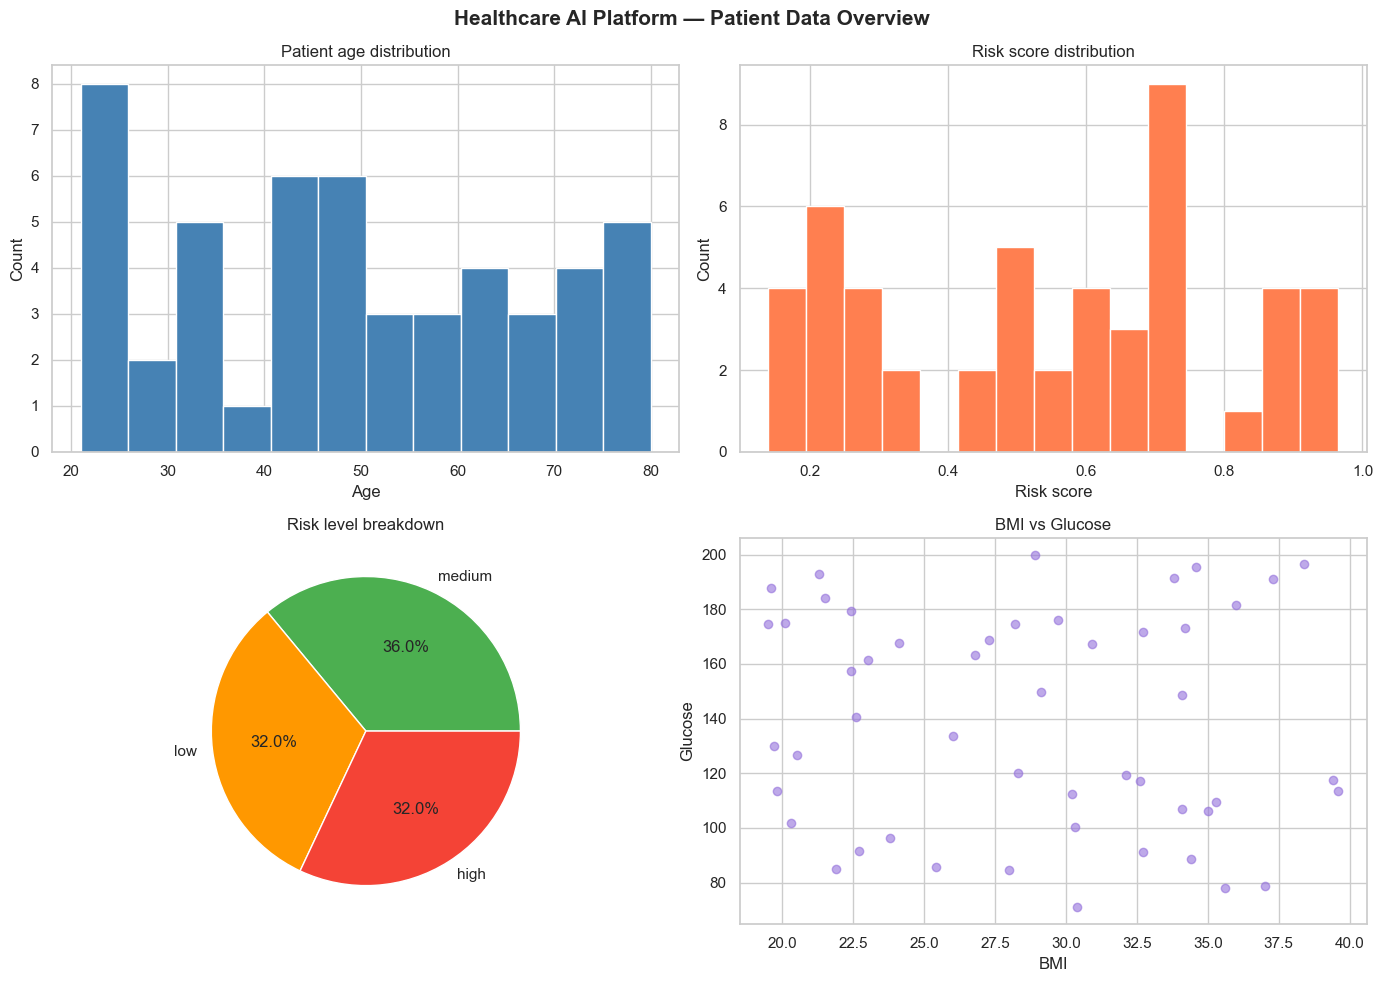

✅ Visualization saved!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Healthcare AI Platform — Patient Data Overview', fontsize=15, fontweight='bold')

with sqlite3.connect(DB_PATH) as conn:
    patients_df = pd.read_sql('SELECT * FROM patients', conn)
    vitals_df   = pd.read_sql('SELECT * FROM vitals', conn)
    preds_df    = pd.read_sql('SELECT * FROM risk_predictions', conn)
    syms_df     = pd.read_sql('SELECT * FROM symptom_logs', conn)

# 1. Age distribution
axes[0,0].hist(patients_df['age'], bins=12, color='steelblue', edgecolor='white')
axes[0,0].set_title('Patient age distribution')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Count')

# 2. Risk score distribution
axes[0,1].hist(preds_df['risk_score'], bins=15, color='coral', edgecolor='white')
axes[0,1].set_title('Risk score distribution')
axes[0,1].set_xlabel('Risk score'); axes[0,1].set_ylabel('Count')

# 3. Risk level breakdown
risk_counts = preds_df['risk_level'].value_counts()
axes[1,0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
              colors=['#4CAF50','#FF9800','#F44336'])
axes[1,0].set_title('Risk level breakdown')

# 4. BMI vs Glucose scatter
axes[1,1].scatter(vitals_df['bmi'], vitals_df['glucose'], alpha=0.6, color='mediumpurple')
axes[1,1].set_title('BMI vs Glucose')
axes[1,1].set_xlabel('BMI'); axes[1,1].set_ylabel('Glucose')

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase1_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualization saved!')

---
## ✅ Phase 1 Complete!

**What you built:**
- Full relational database with 5 tables (patients, vitals, symptoms, predictions, scans)
- Reusable `DatabaseManager` class used in every future phase
- 50 synthetic patients with realistic medical data
- SQL analytics queries and data visualizations

**Next → Phase 2: ML Disease Risk Prediction Model**
- Train XGBoost + Scikit-learn models on patient vitals
- Predict diabetes, heart disease, hypertension risk
- Save trained models for API use